# Dog Breeds Dataset — Data Preprocessing & DataLoader

Author: **Ozor Moya**

**Goal:** 

The goal of this notebook is to prepare the dataset for model training. Building on the findings from Sprint 1, this covers fixing the label bug found in the class distribution, verifying all images are in a consistent format, and addressing the breed imbalance using WeightedRandomSampler. From there, the plan is to define separate transform pipelines for train and val/test splits, build a custom PyTorch Dataset class that loads images directly from the CSV, wrap everything into DataLoaders, and verify a sample batch loads with the correct shape and normalized pixel values.

---
## 1. Import Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

warnings.filterwarnings('ignore')

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ── Plotting defaults ──
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 12
plt.rcParams['axes.titleweight']  = 'normal'

---
## 2. Setting Directory Paths

In [2]:
# ── Paths ──
BASE_DIR = Path('../Data')
CSV_PATH = 'dogs_updated.csv'

# ── Target image size for pretrained backbone ──
IMG_SIZE   = 224
BATCH_SIZE = 32

# ── ImageNet normalization values ──
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

- This section sets up all the constants and paths used throughout the notebook. BASE_DIR points to the folder containing the train, valid, and test image directories, and CSV_PATH points to the dogs.csv file, same paths used in Sprint 1.

- IMG_SIZE is set to 224, which is the standard input size expected by pretrained backbones like ResNet and MobileNet. BATCH_SIZE of 32 controls how many images are fed into the model at once, large enough for stable training, small enough to fit comfortably in memory on a local machine.

- IMAGENET_MEAN and IMAGENET_STD are the normalization values calculated from the entire ImageNet dataset, one value per RGB channel. Since I'm using a pretrained backbone that was originally trained on ImageNet, applying the same normalization ensures our dog images are in the exact pixel range the model expects.

---
## 3. Load & Clean the CSV

In [3]:
df_dogs = pd.read_csv(CSV_PATH)
df_dogs.columns = df_dogs.columns.str.strip()

# ── Fix the double-space issue found in Sprint 1 EDA ──
df_dogs['labels'] = df_dogs['labels'].str.strip().str.replace(r'\s+', ' ', regex=True)

# ── Resolve full paths ──
df_dogs['full_path']   = df_dogs['filepaths'].apply(lambda p: BASE_DIR / p.strip())
df_dogs['file_exists'] = df_dogs['full_path'].apply(lambda p: p.exists())

print(f'Rows loaded   : {len(df_dogs):,}')
print(f'Unique breeds : {df_dogs["labels"].nunique()}')
print(f'Files found   : {df_dogs["file_exists"].sum():,} / {len(df_dogs):,}')
print()
print(df_dogs['data set'].value_counts().rename('count').to_frame())
df_dogs.head()

Rows loaded   : 8,694
Unique breeds : 69
Files found   : 8,692 / 8,694

          count
data set       
train      7325
valid       687
test        682


,filepaths,labels,data set,full_path,file_exists
0,train/Afghan/001.jpg,Afghan,train,../Data/train/Afghan/001.jpg,True
1,train/Afghan/002.jpg,Afghan,train,../Data/train/Afghan/002.jpg,True
2,train/Afghan/008.jpg,Afghan,train,../Data/train/Afghan/008.jpg,True
3,train/Afghan/009.jpg,Afghan,train,../Data/train/Afghan/009.jpg,True
4,train/Afghan/010.jpg,Afghan,train,../Data/train/Afghan/010.jpg,True


- Reapplying the same label cleaning from Sprint 1 to fix the `'American  Spaniel'` double-space issue. This is now a standard load-time step to ensure breed counts stay at 70 and no records get misclassified going into the DataLoader.

In [4]:
# ── Drop rows with missing files ──
before = len(df_dogs)
df_dogs = df_dogs[df_dogs['full_path'].apply(lambda p: p.exists())].reset_index(drop=True)
after = len(df_dogs)
print(f'Dropped {before - after} missing file(s). New total: {after}')

Dropped 2 missing file(s). New total: 8692


- Two files were found missing during DataLoader testing (`Bulldog/023.jpg` and `Bulldog/083.jpg`) — confirmed not present on disk despite being listed in the CSV. Both rows are dropped here before building the rest of the pipeline so the DataLoader doesn't crash trying to open them.

---
## 4. File Format Check

Confirming all images are in a consistent format (JPEG or PNG) before building the pipeline.

In [5]:
extensions = df_dogs['filepaths'].apply(lambda p: Path(p).suffix.lower()).value_counts()

print('File format breakdown:')
print(extensions.to_frame(name='count'))

non_standard = df_dogs[~df_dogs['filepaths'].apply(
    lambda p: Path(p).suffix.lower() in ['.jpg', '.jpeg', '.png']
)]

if len(non_standard) == 0:
    print('\n  All files are JPEG or PNG — no conversion needed')
else:
    print(f'\n  {len(non_standard)} files with non-standard formats:')
    display(non_standard[['filepaths', 'labels', 'data set']].head(10))

File format breakdown:
           count
filepaths       
.jpg        8692

  All files are JPEG or PNG — no conversion needed


- Checking file extensions across all 9,346 records to confirm format consistency. Since the EDA found no corrupted or unreadable files, I expect everything to be JPEG. Any outliers would need to be converted to JPEG or PNG before being passed into the transform pipeline.

---
## 5. Build the Label Encoder

Mapping breed names to integer class indices so PyTorch can work with them.

In [6]:
# ── Create sorted breed → index mapping ──
breeds      = sorted(df_dogs['labels'].unique())
label2idx   = {breed: idx for idx, breed in enumerate(breeds)}
idx2label   = {idx: breed for breed, idx in label2idx.items()}

df_dogs['label_idx'] = df_dogs['labels'].map(label2idx)

print(f'Total classes : {len(breeds)}')
print(f'\nSample mappings:')
for breed, idx in list(label2idx.items())[:5]:
    print(f'  {idx:>3}  →  {breed}')

Total classes : 69

Sample mappings:
    0  →  Afghan
    1  →  African Wild Dog
    2  →  Airedale
    3  →  American Hairless
    4  →  American Spaniel


- PyTorch's loss functions expect integer class indices, not string breed names. Sorting alphabetically before assigning indices keeps the mapping deterministic, the same breed will always get the same index regardless of how the CSV is ordered.

---
## 6. Define Transforms

Augmentation is applied to the **training split only**. Validation and test get resize and normalize only — no augmentation, so evaluation is done on clean unmodified images.

In [7]:
# ── Training transforms — resize + augmentation + normalize ──
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ── Validation and test transforms — resize + normalize only ──
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Train transforms:')
print(train_transforms)
print()
print('Val / Test transforms:')
print(val_test_transforms)

Train transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val / Test transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


- Since I'm using a pretrained backbone (ResNet or MobileNet), normalization uses ImageNet mean and std values `([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])`. The backbone was trained on these exact values, so matching them ensures the pretrained weights activate correctly on our data.

- Augmentation choices are intentionally conservative — horizontal flip, small rotation (±15°), and mild color jitter. These mimic realistic variation in dog photos (different angles, lighting, camera settings) without distorting the images beyond recognition. American Hairless, being the only under-represented breed at 65 images, benefits the most from this augmentation during training.

### Visualize Augmentation Effect

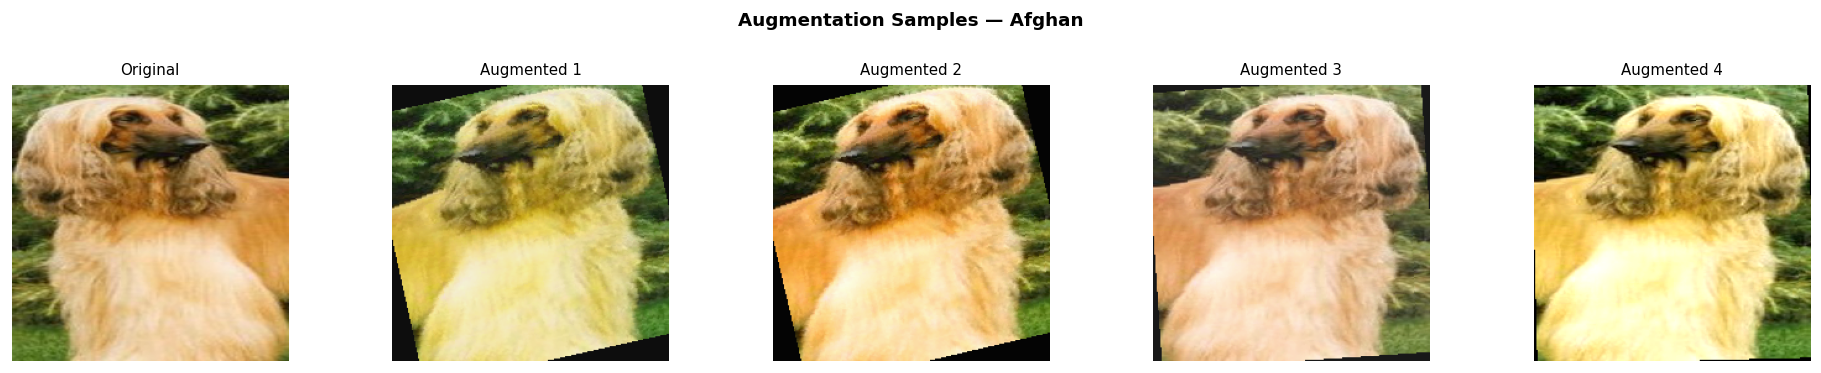

In [8]:
# ── Show original vs augmented for one sample image ──
sample_row = df_dogs[df_dogs['file_exists']].iloc[0]
orig_img   = Image.open(sample_row['full_path']).convert('RGB')

# Augment without normalization so we can visualize it
aug_only = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
])

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(orig_img.resize((IMG_SIZE, IMG_SIZE)))
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for i in range(1, 5):
    axes[i].imshow(aug_only(orig_img))
    axes[i].set_title(f'Augmented {i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle(f'Augmentation Samples — {sample_row["labels"]}', fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('aug_samples.png', dpi=150, bbox_inches='tight')
plt.show()

- Each augmented version looks like a plausible real-world photo of the same dog, different angle, slightly different lighting, sometimes flipped. The model will see a different variation of each image every epoch, which helps it generalize rather than memorize.

---
## 7. Custom PyTorch Dataset Class

Since the dataset is organized via a CSV file rather than a standard `ImageFolder` structure, a custom Dataset class is needed. It reads one row at a time, opens the image from its full path, and applies the correct transform based on which split the image belongs to.

In [9]:
class DogBreedDataset(Dataset):
    """
    Custom Dataset for the dog breed classification task.
    Reads image paths and labels from a pandas DataFrame.
    Applies the correct transform based on the split.
    """

    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe : filtered DataFrame for one split (train / valid / test)
            transform : torchvision transform pipeline to apply
        """
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        """Returns the total number of images in this split."""
        return len(self.df)

    def __getitem__(self, idx):
        """
        Loads one image and its label by index.
        Returns a (tensor, label_index) tuple.
        """
        row   = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = int(row['label_idx'])
        return image, label


# ── Split the DataFrame by split column ──
train_df = df_dogs[df_dogs['data set'] == 'train'].reset_index(drop=True)
val_df   = df_dogs[df_dogs['data set'] == 'valid'].reset_index(drop=True)
test_df  = df_dogs[df_dogs['data set'] == 'test'].reset_index(drop=True)

# ── Instantiate datasets ──
train_dataset = DogBreedDataset(train_df, transform=train_transforms)
val_dataset   = DogBreedDataset(val_df,   transform=val_test_transforms)
test_dataset  = DogBreedDataset(test_df,  transform=val_test_transforms)

print(f'Train dataset : {len(train_dataset):,} images')
print(f'Val dataset   : {len(val_dataset):,} images')
print(f'Test dataset  : {len(test_dataset):,} images')

Train dataset : 7,323 images
Val dataset   : 687 images
Test dataset  : 682 images


- The `__len__` method tells PyTorch how many items are in the dataset. The `__getitem__` method is called once per image during training it opens the file, applies the transform, and returns the image tensor paired with its integer class label. The `convert('RGB')` call is a safety measure to handle any grayscale or RGBA images that might sneak through.

---
## 8. Handle Class Imbalance with WeightedRandomSampler

Based on the Sprint 1 EDA findings — Shih-Tzu at 198 vs American Hairless at 65, our team decided to apply `WeightedRandomSampler` so underrepresented breeds appear more frequently during training.

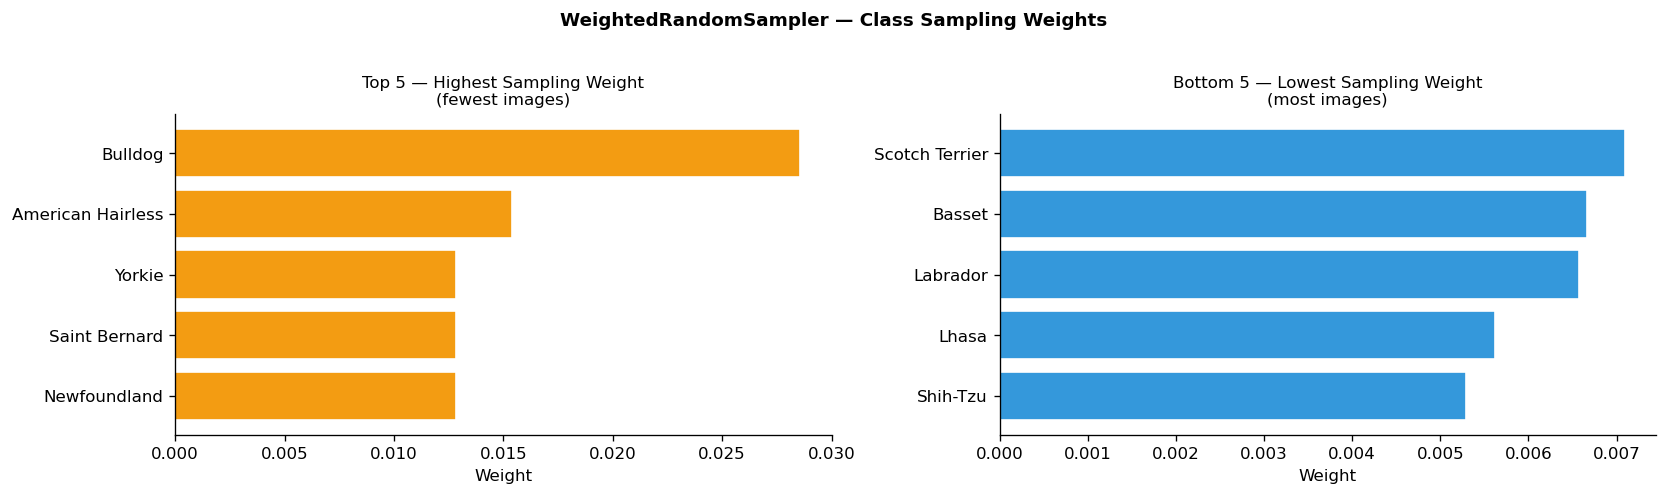

Highest weight : Bulldog  (0.02857)
Lowest weight  : Shih-Tzu  (0.00529)


In [10]:
# ── Compute per-class weights (inverse of class frequency) ──
class_counts  = train_df['label_idx'].value_counts().sort_index().values
class_weights = 1.0 / class_counts

# ── Assign each training sample its class weight ──
sample_weights = torch.tensor(
    [class_weights[idx] for idx in train_df['label_idx'].values],
    dtype=torch.float
)

# ── Build the sampler ──
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── Visualize class weights for top and bottom 5 breeds ──
weight_df = pd.DataFrame({
    'breed'  : [idx2label[i] for i in range(len(class_counts))],
    'count'  : class_counts,
    'weight' : class_weights
}).sort_values('weight', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top5    = weight_df.head(5)
bottom5 = weight_df.tail(5)

axes[0].barh(top5['breed'], top5['weight'], color='#f39c12', edgecolor='white')
axes[0].set_title('Top 5 — Highest Sampling Weight\n(fewest images)', fontsize=10)
axes[0].set_xlabel('Weight')
axes[0].invert_yaxis()

axes[1].barh(bottom5['breed'], bottom5['weight'], color='#3498db', edgecolor='white')
axes[1].set_title('Bottom 5 — Lowest Sampling Weight\n(most images)', fontsize=10)
axes[1].set_xlabel('Weight')
axes[1].invert_yaxis()

plt.suptitle('WeightedRandomSampler — Class Sampling Weights', fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sampler_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Highest weight : {weight_df.iloc[0]["breed"]}  ({weight_df.iloc[0]["weight"]:.5f})')
print(f'Lowest weight  : {weight_df.iloc[-1]["breed"]}  ({weight_df.iloc[-1]["weight"]:.5f})')

- Breeds with fewer training images get a higher sampling weight, meaning they'll be drawn more frequently during each epoch. Breeds with more images get a lower weight so they don't dominate training. This directly addresses the imbalance flagged in Sprint 1 without removing any data from the dataset. `replacement=True` is required here, without it, underrepresented breeds would run out of samples before the epoch ends.

---
## 9. Build the DataLoaders

In [11]:
# ── Train loader uses sampler instead of shuffle ──
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,        # replaces shuffle=True
    num_workers=0,
    pin_memory=True
)

# ── Val and test loaders — no sampler, no shuffle ──
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'Batch size    : {BATCH_SIZE}')

Train batches : 229
Val batches   : 22
Test batches  : 22
Batch size    : 32


- This section wraps the three datasets into DataLoaders — the objects PyTorch uses to feed batches of images into the model. The train loader uses the WeightedRandomSampler instead of `shuffle=True` since the sampler already handles randomization while balancing breed frequencies. Val and test loaders use `shuffle=False` so evaluation results are consistent and reproducible across runs. `num_workers=0` is set for all three to avoid multiprocessing issues on Mac.

- I tried using `num_workers=2` on my first run but it takes too long to process thats why I decided to go with 0 to speed up the process while using this local machine.

---
## 10. Verify a Sample Batch

Confirming the DataLoader is working correctly by pulling one batch and checking shape, data type, and pixel value range.

In [12]:
images, labels = next(iter(train_loader))

print('── Batch Verification ──────────────────────')
print(f'Image tensor shape : {images.shape}')        # expect [32, 3, 224, 224]
print(f'Labels shape       : {labels.shape}')        # expect [32]
print(f'Image dtype        : {images.dtype}')        # expect torch.float32
print(f'Labels dtype       : {labels.dtype}')        # expect torch.int64
print(f'Pixel min          : {images.min():.4f}')    # expect ~ -2.1
print(f'Pixel max          : {images.max():.4f}')    # expect ~  2.6
print(f'Pixel mean         : {images.mean():.4f}')   # expect ~  0.0
print(f'Unique labels      : {labels.unique().tolist()}')
print('────────────────────────────────────────────')

# ── Quick shape assertion ──
assert images.shape == (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE), 'Unexpected image batch shape'
assert images.dtype == torch.float32, 'Expected float32 tensors'
print('\n  All assertions passed — DataLoader is ready')

── Batch Verification ──────────────────────
Image tensor shape : torch.Size([32, 3, 224, 224])
Labels shape       : torch.Size([32])
Image dtype        : torch.float32
Labels dtype       : torch.int64
Pixel min          : -2.1179
Pixel max          : 2.6400
Pixel mean         : -0.0138
Unique labels      : [2, 5, 6, 8, 10, 15, 16, 17, 18, 19, 21, 26, 29, 30, 40, 41, 42, 45, 47, 48, 58, 64, 67]
────────────────────────────────────────────

  All assertions passed — DataLoader is ready


### Visualize a Sample Batch

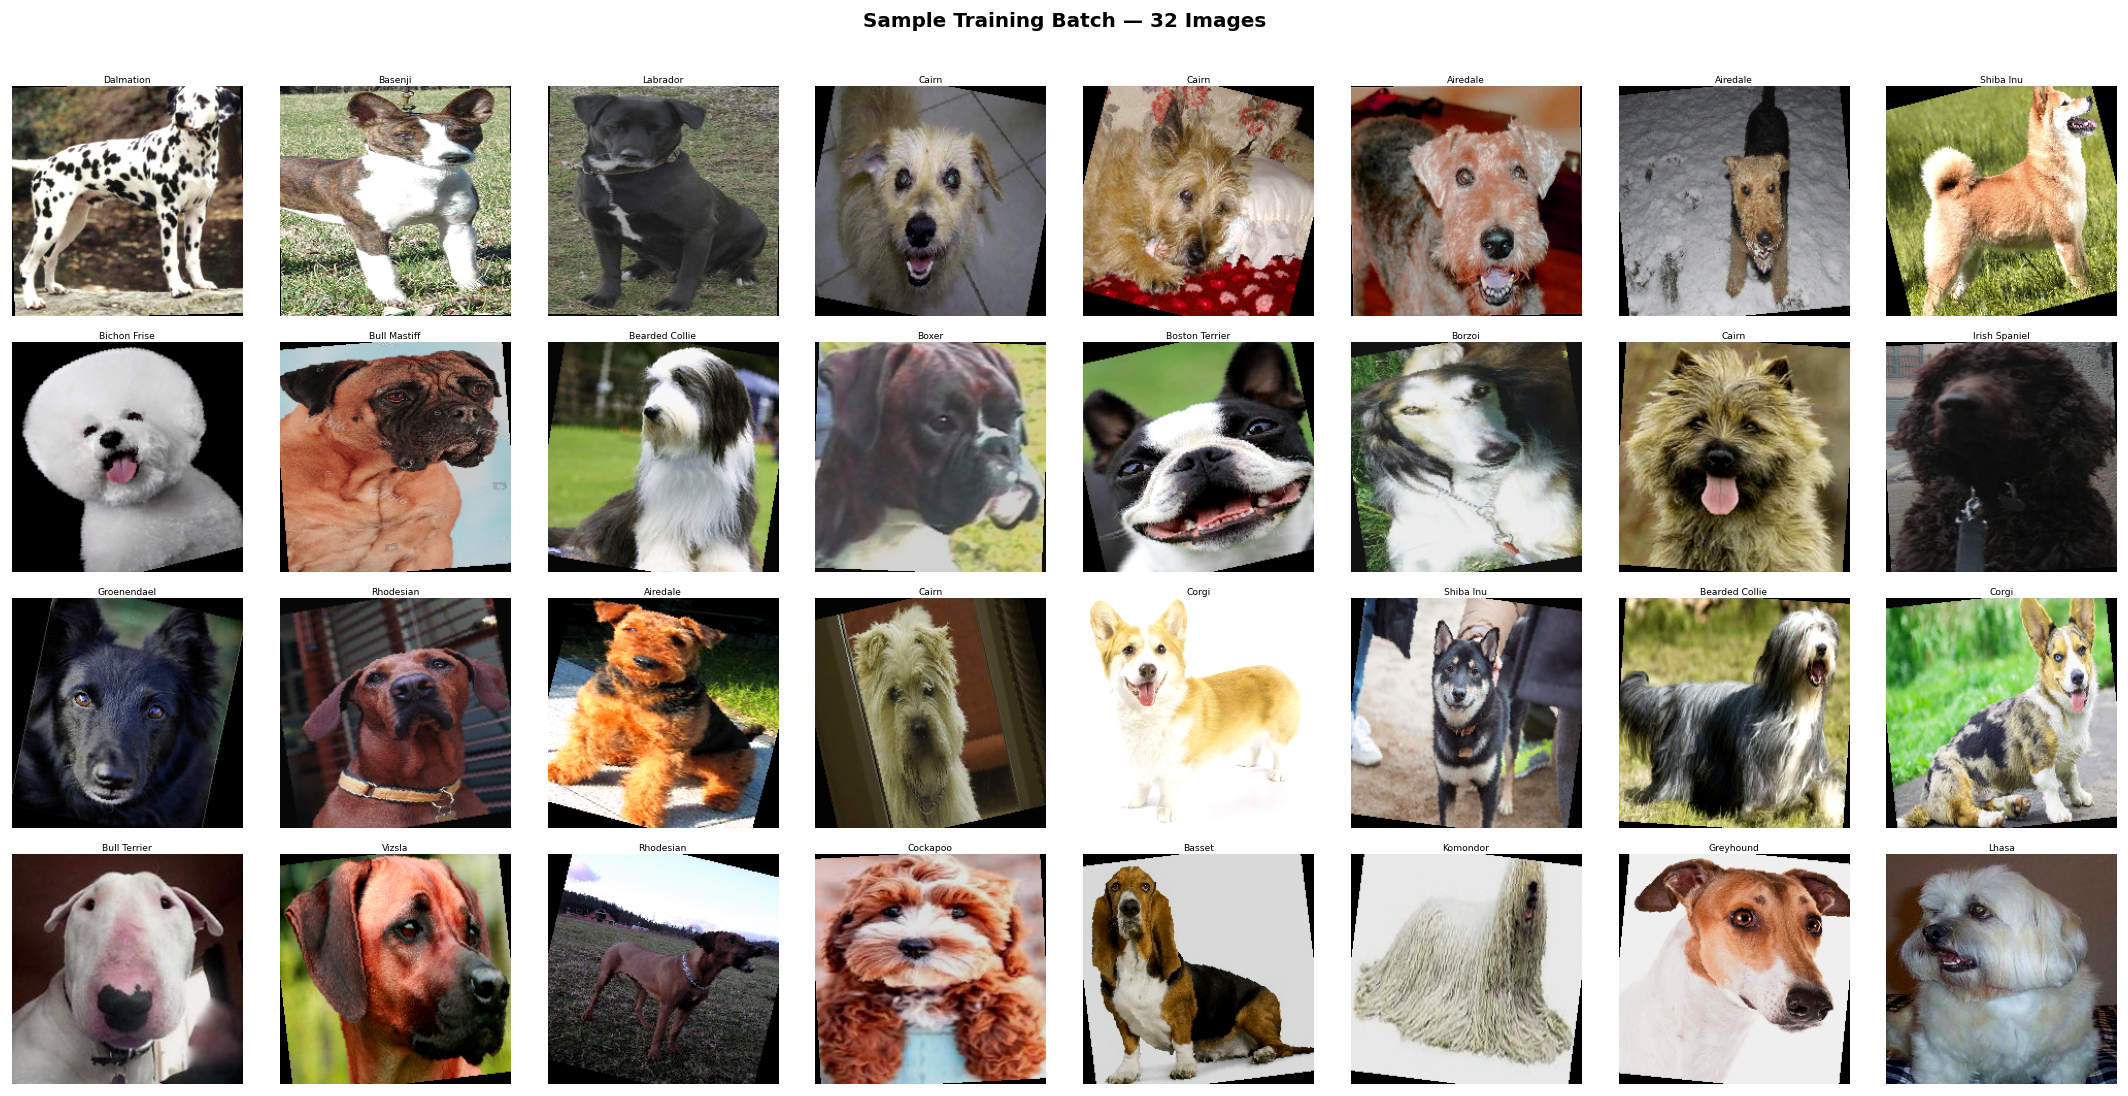

In [13]:
def denormalize(tensor):
    """Reverse ImageNet normalization for visualization."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
axes = axes.flatten()

for i in range(32):
    img   = denormalize(images[i]).permute(1, 2, 0).numpy()
    label = idx2label[labels[i].item()]
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=5.5, pad=2)
    axes[i].axis('off')

plt.suptitle('Sample Training Batch — 32 Images', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_batch.png', dpi=150, bbox_inches='tight')
plt.show()

- Denormalization reverses the ImageNet normalization so images display correctly, without this step, the pixel values would be outside the 0–1 range and render as washed-out or distorted visuals. This grid is a final sanity check that images and labels are correctly paired and augmentations look reasonable.

---
## 11. Verify Sampler Balance

Checking that `WeightedRandomSampler` is actually evening out breed frequencies across one epoch.

Most sampled class  : 132 images
Least sampled class : 91 images
Mean per class      : 106.1
Std dev             : 9.0


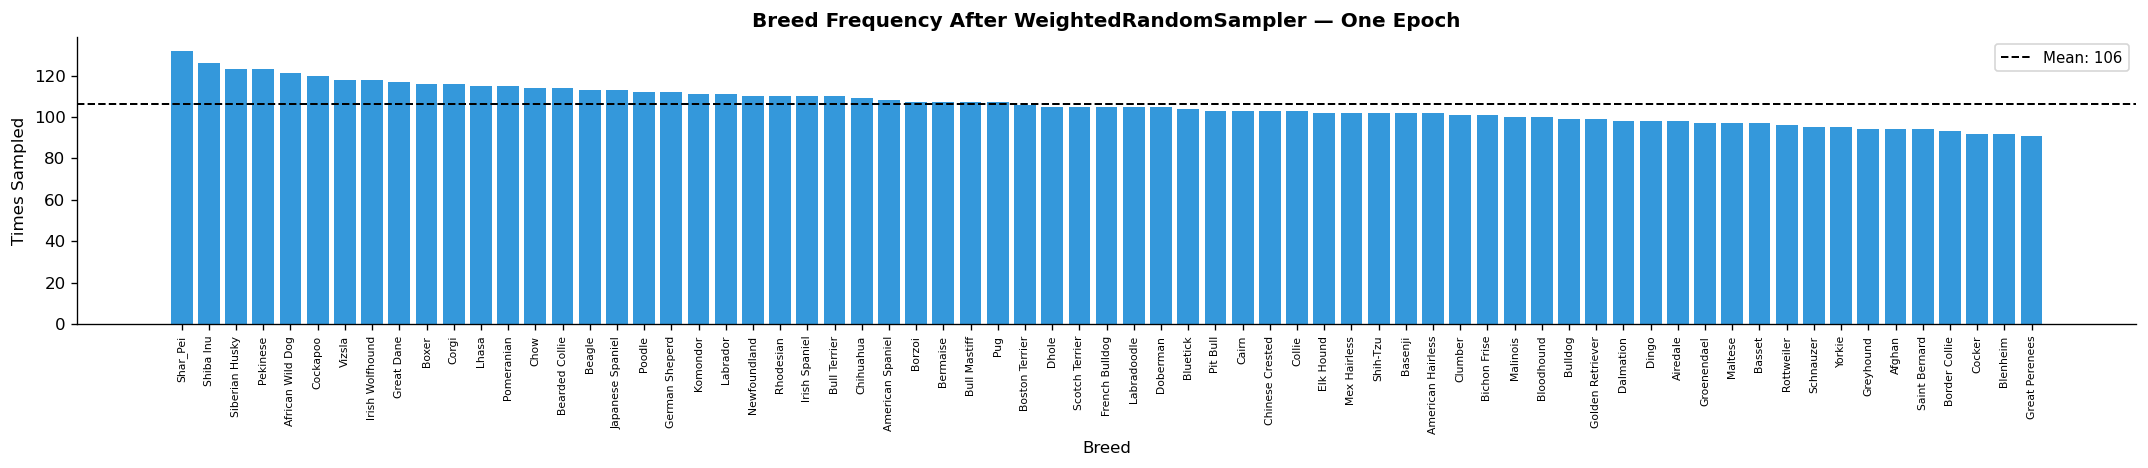

In [14]:
label_counts = Counter()
for _, batch_labels in train_loader:
    label_counts.update(batch_labels.numpy())

counts_arr = np.array(list(label_counts.values()))

print(f'Most sampled class  : {counts_arr.max()} images')
print(f'Least sampled class : {counts_arr.min()} images')
print(f'Mean per class      : {counts_arr.mean():.1f}')
print(f'Std dev             : {counts_arr.std():.1f}')

# ── Plot distribution after sampling ──
fig, ax = plt.subplots(figsize=(18, 4))
sorted_counts = sorted(label_counts.items(), key=lambda x: -x[1])
breed_names   = [idx2label[k] for k, _ in sorted_counts]
breed_vals    = [v for _, v in sorted_counts]

ax.bar(breed_names, breed_vals, color='#3498db', edgecolor='none', width=0.8)
ax.axhline(counts_arr.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Mean: {counts_arr.mean():.0f}')
ax.set_title('Breed Frequency After WeightedRandomSampler — One Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Breed'); ax.set_ylabel('Times Sampled')
ax.tick_params(axis='x', rotation=90, labelsize=6.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('sampler_balance.png', dpi=150, bbox_inches='tight')
plt.show()

- After applying WeightedRandomSampler, breed frequency is now much more evenacross one epoch. The most sampled breed (Shar_Pei, ~132) and least sampled (Great Pyrenees, ~90) sit far closer together than the raw training countsfrom Sprint 1, where the gap was 198 vs 65. All breeds now cluster tightly around the mean of 106, confirming the sampler is successfully correcting for class imbalance — no breed is being significantly over- or under-represented during training anymore.

---
## 12. Summary

### What Was Done

**Label cleaning** was reapplied at load time to fix the `'American  Spaniel'` double-space issue found in Sprint 1.

**Dataset update** — this notebook now uses Cameron's cleaned `dogs_updated.csv`, which removed one non-dog breed and a number of mislabeled images, bringing the dataset to 69 breeds. Two additional missing files (`Bulldog/023.jpg`, `Bulldog/083.jpg`) were found during DataLoader testing and dropped, leaving a final total of 8,692 images.

**File format check** confirmed all remaining images are in a consistent JPEG/PNG format with no conversions needed.

**Label encoding** mapped all 69 breed names to integer class indices in a sorted, deterministic order so the mapping stays consistent across runs.

**Transform pipelines** were defined separately for train and val/test splits. Training images receive random horizontal flip, rotation (±15°), and color jitter before normalization. Validation and test images are only resized and normalized, no augmentation, so evaluation reflects true model performance on unmodified images.

**Normalization** uses ImageNet mean `[0.485, 0.456, 0.406]` and std `[0.229, 0.224, 0.225]` to match the input distribution expected by pretrained backbones like ResNet and MobileNet.

**WeightedRandomSampler** was applied to the training DataLoader to address class imbalance. After sampling, breed frequency per epoch evened out significantly, the highest (Shar_Pei, ~132) and lowest (Great Pyrenees, ~90) sampled breeds now sit close to the mean of 106, compared to the much wider raw gap seen in the original Sprint 1 distribution.

**Batch verification** confirmed the pipeline is producing correctly shaped tensors `[32, 3, 224, 224]` with normalized pixel values in the expected range and labels properly paired to images.